In [1]:
import sys
sys.path.append('../src')

from IPython.display import display, clear_output
from PIL import Image, ImageOps, ImageDraw, ImageFont, ImageChops
import matplotlib.pyplot as plt
import numpy as np

from palette.symbol2value import get_asciis, symbols_sorted
from image.processing import preprocess_img
from rendering.image import render_symbols_img
from converters.line_heuristics.utils import evaluate_symbol_arr

In [2]:
FONT = ImageFont.truetype("../fonts/OpenSans-Regular.ttf", 18)
# FONT = ImageFont.truetype("../fonts/CascadiaMono.ttf", 18)

CHAR_SET = symbols_sorted(get_asciis(), FONT)[::2]
print(CHAR_SET)
print(len(CHAR_SET))

IMG_PATH = "../imgs/irad_grad.bmp"

[' ', '`', ',', ':', ';', '"', 'i', '+', '<', '>', '^', 'r', '?', 't', ')', 'c', 'f', 'J', '{', '7', 'v', ']', 'T', 'F', 'o', 'C', 'a', 'y', '5', 'S', '4', 'X', '6', 'P', '9', 'U', 'b', 'p', '$', 'H', 'G', 'O', 'w', 'g', 'N', '&', '@', 'W']
48


(512, 512)
(102, 102)


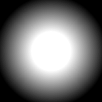

In [3]:
orig_img = Image.open(IMG_PATH).convert("L")
print(orig_img.size)
prep_img = preprocess_img(orig_img, 0.2, contrast=2.0)
print(prep_img.size)
display(prep_img)

[[' ', ' ', ' ', ' ', ' ', 'g', 'g', 'g', 'g', 'g', ',', ' ', ' ', ' ', ' ', ' '], [' ', '@', '@', '@', '@', '@', 'J', ',', ' ', ' '], [' ', 'W', 'W', '@', '@', '@', 'J', ' ', ' '], [' ', ' ', ' ', ' ', '"', 'W', 'W', '$', '"', '"', ' ', ' ', ' ', ' ']]
-16418.824394463667


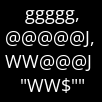

In [4]:
from converters.line_heuristics.greedy import GreedyLineSearch

res_arr = GreedyLineSearch(CHAR_SET, FONT).process_image(prep_img)
print(res_arr)
print(evaluate_symbol_arr(prep_img, res_arr, FONT, prep_img.size))
display(render_symbols_img(res_arr, FONT, wh=prep_img.size))

0 -8596.506944444445
0 -26832.34844771242
0 -30742.323529411766
0 -13307.361928104576
[['?', 'v', ' ', 'C', 'f', '$', ';', '+', '+', '`', '{', '"', '4'], ['i', 'U', 'O', '9', '5', '>', '4', 'X', '6', 'i'], ['r', 'g', 'U', 'p', ',', '$', '&', ':', 'p', 'p'], ['{', ' ', 'b', '^', 'F', 'N', 'N', '&', 't', 'i', '+']]
-18755.046424452135


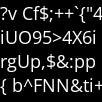

In [5]:
from converters.line_heuristics.random_search import RandomLineSearch

res_arr = RandomLineSearch(CHAR_SET, FONT, 1).process_image(prep_img)
print(res_arr)
print(evaluate_symbol_arr(prep_img, res_arr, FONT, prep_img.size))
display(render_symbols_img(res_arr, FONT, wh=prep_img.size))

-1 -7982.763888888889
0 -7725.326797385621
2 -7599.028594771242
6 -7400.007352941177
9 -7392.771241830065
12 -7127.569035947712
31 -7101.0424836601305
33 -7068.667075163398
35 -6790.674019607844
40 -6356.470996732026
63 -6287.044934640523
128 -6197.888071895425
-1 -26130.95588235294
0 -26016.835375816994
1 -25940.142973856207
2 -25022.906862745098
6 -24984.608660130718
7 -24416.706290849674
19 -24367.18341503268
20 -24281.383986928104
21 -24201.78022875817
27 -23909.015522875816
32 -23837.92156862745
78 -23791.715277777777
111 -23581.5102124183
123 -23472.601307189543
198 -23428.68954248366
-1 -30228.950571895424
0 -29916.616421568626
3 -29852.628267973858
4 -29575.371323529413
9 -29486.37091503268
13 -29459.54575163399
16 -29232.460375816994
23 -29122.25612745098
35 -29021.898692810457
37 -28988.035539215685
55 -28730.86887254902
57 -28595.10906862745
69 -28342.95751633987
139 -28273.63929738562
190 -28102.97385620915
-1 -13399.934232026144
0 -12982.441993464052
1 -12560.711192810457


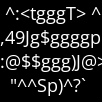

In [6]:
from converters.line_heuristics.harmony_search import HarmonyLineSearch

res_arr = HarmonyLineSearch(CHAR_SET, FONT, generations=200, pop_count=20, mem_rate=0.6, pa_rate=0.2, pa=len(CHAR_SET) // 4).process_image(prep_img)
print(evaluate_symbol_arr(prep_img, res_arr, FONT, prep_img.size))
print(res_arr)
display(render_symbols_img(res_arr, FONT, wh=prep_img.size))


In [7]:
# from converters.line_heuristics.genetic_search import GeneticLineSearch

# res_arr = GeneticLineSearch(CHAR_SET, FONT, 300).process_image(prep_img)
# print(evaluate_symbol_arr(prep_img, res_arr, FONT, prep_img.size))
# display(render_symbols_img(res_arr, FONT, wh=prep_img.size))

In [8]:
# from converters.line_heuristics.pso_search import ParticleSwarmLineSearch

# res_arr = ParticleSwarmLineSearch(CHAR_SET, FONT, innertion=0.3, cog_coeff=1.0, soc_coeff=3.0, generations=100, pop_count=100).process_image(prep_img)
# print(res_arr)
# print(evaluate_symbol_arr(prep_img, res_arr, FONT, prep_img.size))
# display(render_symbols_img(res_arr, FONT, wh=prep_img.size))